In [72]:
import pickle
import os
import sys
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import scipy.io
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sns; sns.set_theme(style="whitegrid")
# import scrublet as scr
# import diffxpy.api as de
# import gseapy
import gc

# sc.settings.verbosity = 3
# sc.logging.print_versions()

def set_nature_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,

        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3,
        "ytick.major.size": 3,

        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.transparent": True,
        "savefig.bbox": "tight",
    })

set_nature_style()

In [2]:
model_dir = "/local/home/am/EX_M/scDAE_mn_7/mask_retrieve"

In [3]:
merged_data = sc.read('/local/home/am/EX_M/datasets/scRNA/merged/seed_32/scFoundation/validation/bone_marrow_val_processed.h5ad')
merged_data

AnnData object with n_obs × n_vars = 67626 × 19264
    obs: 'dataset', 'sample', 'donor_status', 'donor', 'timepoint', 'celltype', 'n_genes', 'set', 'ID', 'label'
    uns: 'celltype_colors', 'dataset_colors', 'hvg', 'neighbors', 'timepoint_colors', 'umap'

In [4]:
def read_pickle(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    return data

In [5]:
# read from pickle file
maskings = read_pickle(model_dir + '/maskings.pkl')
samples = read_pickle(model_dir + '/samples.pkl')

In [6]:
maskings.shape

torch.Size([67626, 19264])

In [7]:
samples.shape

torch.Size([67626])

In [8]:
import numpy as np
import pandas as pd

# — assume you have:
#    maskings:  torch.BoolTensor of shape (n_cells, n_genes),
#               where False means “this gene was masked” 
#    saved_ids: sequence of length n_cells giving the cell‐IDs
#               (in the same order as maskings’ rows)
#    adata.obs['ID']: the original cell‐IDs in the AnnData

# 1) Convert to NumPy
mask_np = maskings.cpu().numpy()    # shape: (n_cells, n_genes)
samples_np = np.array(samples)         # shape: (n_cells,)
# 2) Build a map from cell‐ID → row in mask_np
id2row = {cid: i for i, cid in enumerate(samples_np)}

# 3) For each row in adata.obs get the corresponding mask‐row index
row_idx = merged_data.obs['ID'].map(id2row).values

# 4) Realign mask matrix to adata order
mask_aligned = mask_np[row_idx, :]  # shape still (n_cells, n_genes)

# 5) Count per‐gene how many times it was masked
#    (i.e. how many Falses in each column)
mask_counts = (~mask_aligned).sum(axis=0)

# 6) Make a Pandas series indexed by gene name
gene_mask_counts = pd.Series(mask_counts, index=merged_data.var_names)

# also write the avaregae value of masked genes 
avg_mask_count = gene_mask_counts.mean()
avg_mask_frac  = avg_mask_count / mask_aligned.shape[0]

# 7) Sort descending and show the top 20 most‐masked genes
top20 = gene_mask_counts.sort_values(ascending=False).head(20)
print(top20)


C12orf4     20773
SPRR1A      20702
CYP2D6      20702
ENOX1       20694
TAF6        20690
SAMM50      20687
BOK         20680
DNM1L       20680
TTLL8       20678
TMEM151B    20674
NEMF        20669
HSPB1       20667
DENR        20666
TBC1D19     20665
WASF2       20663
DGKZ        20662
CLEC4E      20659
GUCY2C      20657
SDF2L1      20657
APOA5       20656
dtype: int64


In [32]:
import numpy as np
import pandas as pd
from scipy import sparse

# 1) Pull out your AnnData object and the mask matrix
#    Replace `adata` with your AnnData variable
expr = merged_data.X
mask = mask_aligned   # shape: (n_cells, n_genes), False = masked

# 2) Convert to dense if needed
if sparse.issparse(expr):
    expr = expr.toarray()

# 3) Count masks per gene
mask_counts = (~mask).sum(axis=0)  # how many times each gene was masked

# 4) Sum expression values at masked positions, per gene
masked_expr_sum = (expr * (~mask)).sum(axis=0)

# 5) Compute average expression *when masked*, per gene
avg_expr_masked = np.zeros_like(mask_counts, dtype=float)
nonzero = mask_counts > 0
avg_expr_masked[nonzero] = masked_expr_sum[nonzero] / mask_counts[nonzero]

# 6) Build a summary DataFrame
df = pd.DataFrame({
    'mask_count': mask_counts,
    'avg_expr_masked': avg_expr_masked
}, index=merged_data.var_names)

# 7) View the top 100 most‐masked genes along with their average masked expression
df.sort_values('mask_count', ascending=False, inplace=True)


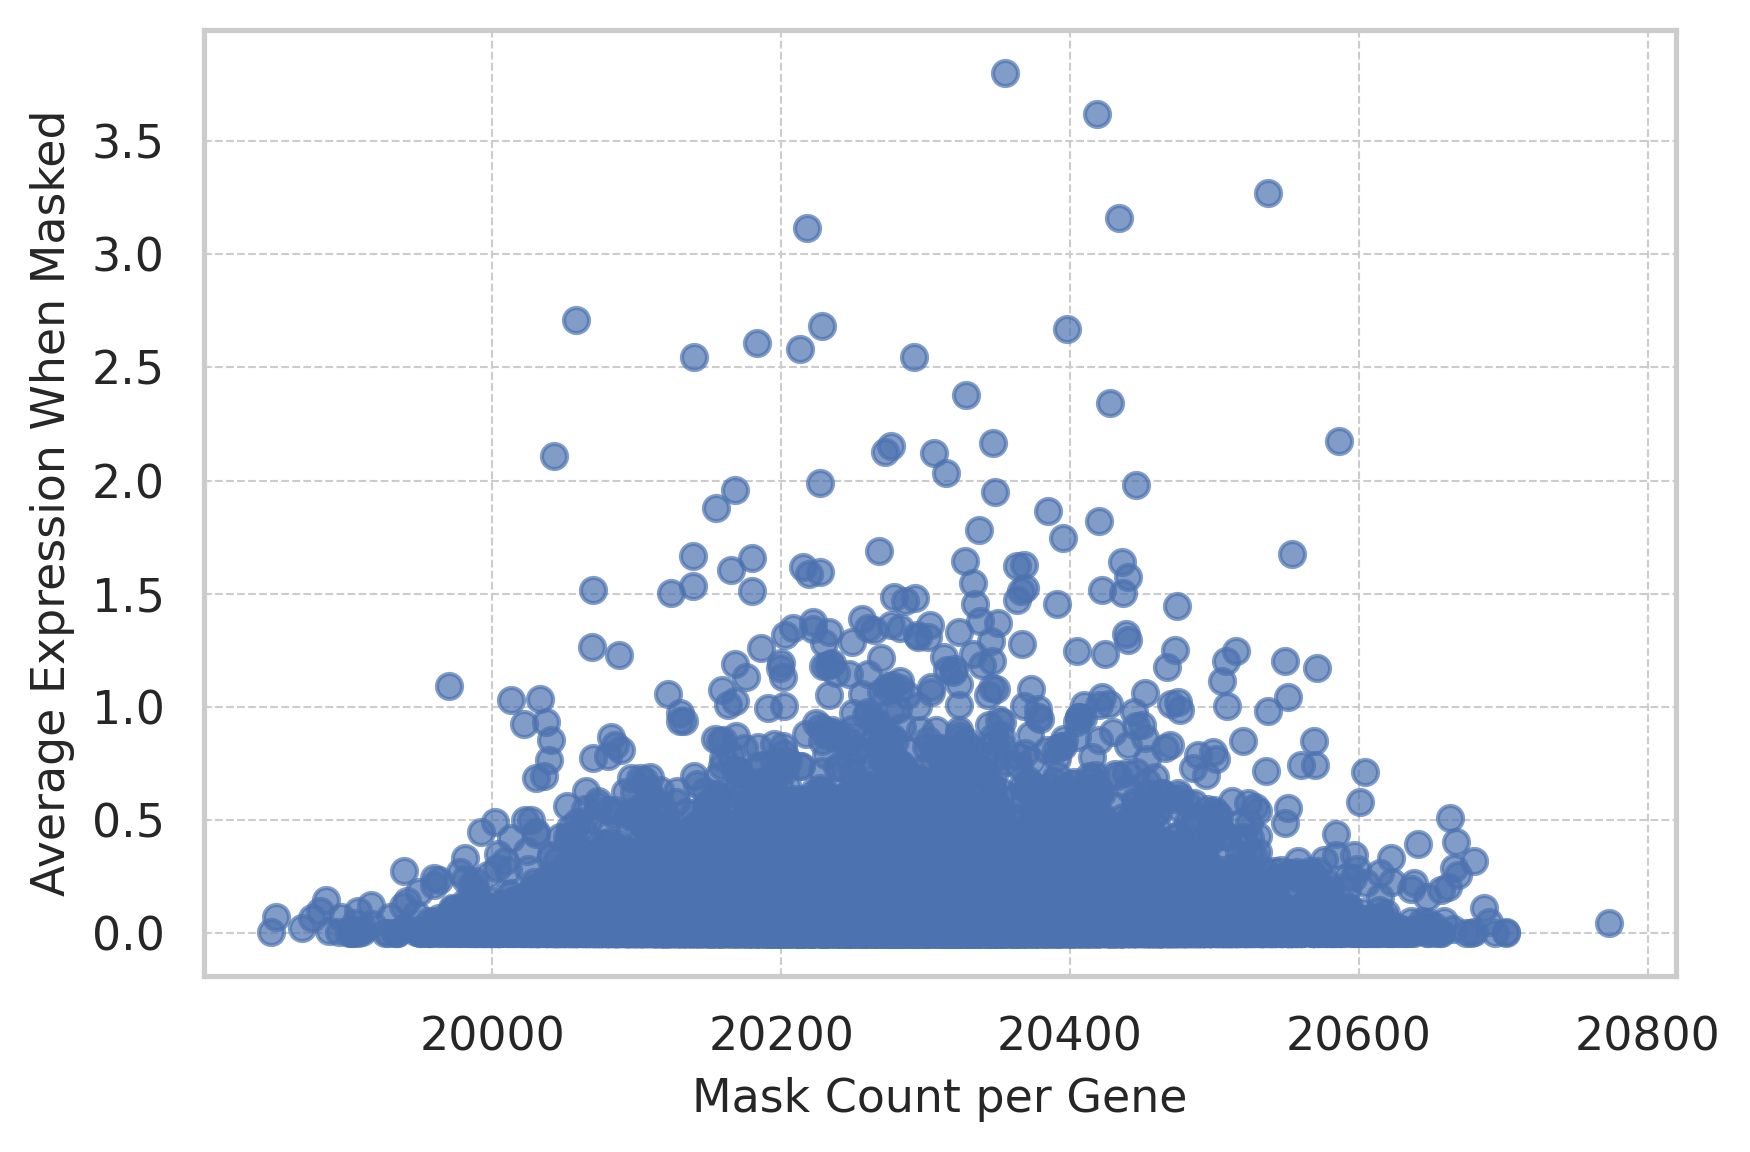

In [86]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['mask_count'], df['avg_expr_masked'], alpha=0.7)
ax.set_xlabel('Mask Count per Gene', fontsize=11)
ax.set_ylabel('Average Expression When Masked', fontsize=11)
# ax.set_title('Masking Frequency vs. Expression Level', fontsize=14)
ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# save the figure as a pdf
fig.savefig('./masking_frequency_vs_expression_level.pdf', bbox_inches='tight', dpi=300)
# save the figure as a png

In [17]:
import gseapy

In [18]:
gene_set_names = gseapy.get_library_name(organism='Human')

In [66]:
enr_res1 = gseapy.enrichr(gene_list=df.head(20000).index.to_list(), organism='Human', gene_sets=['GO_Biological_Process_2025'], cutoff = 0.5)
enr_res1.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of DNA-templated Transcription (GO:...,2130/2139,1.770657e-25,9.460618e-22,0,0,10.041827,572.316636,SPI1;SCX;SPIB;SPIC;MEIOSIN;GPBP1;BBX;FOXO3B;SU...
1,GO_Biological_Process_2025,Regulation of Transcription by RNA Polymerase ...,2238/2250,1.858909e-24,4.966076e-21,0,0,7.930577,433.342991,SPI1;SCX;NOC2L;SLA2;SPIB;SPIC;MEIOSIN;TBK1;ZC3...
2,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,1270/1274,1.167782e-16,2.079820e-13,0,0,12.915972,473.838645,PID1;SPI1;SCX;RBPJ;SPIB;IL4I1;PSMD9;TBK1;ZC3H1...
3,GO_Biological_Process_2025,Negative Regulation of DNA-templated Transcrip...,1002/1006,1.879417e-12,2.510431e-09,0,0,10.040850,271.103546,SPI1;EHMT2;EHMT1;NOC2L;RBPJ;SLA2;SAMD11;MEF2A;...
4,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,979/983,4.238643e-12,4.529414e-09,0,0,9.798031,256.578866,PID1;SPI1;PWWP2B;SCX;RBPJ;SPIB;IL4I1;TBK1;ZC3H...


/tmp/ipykernel_368200/1069907358.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)


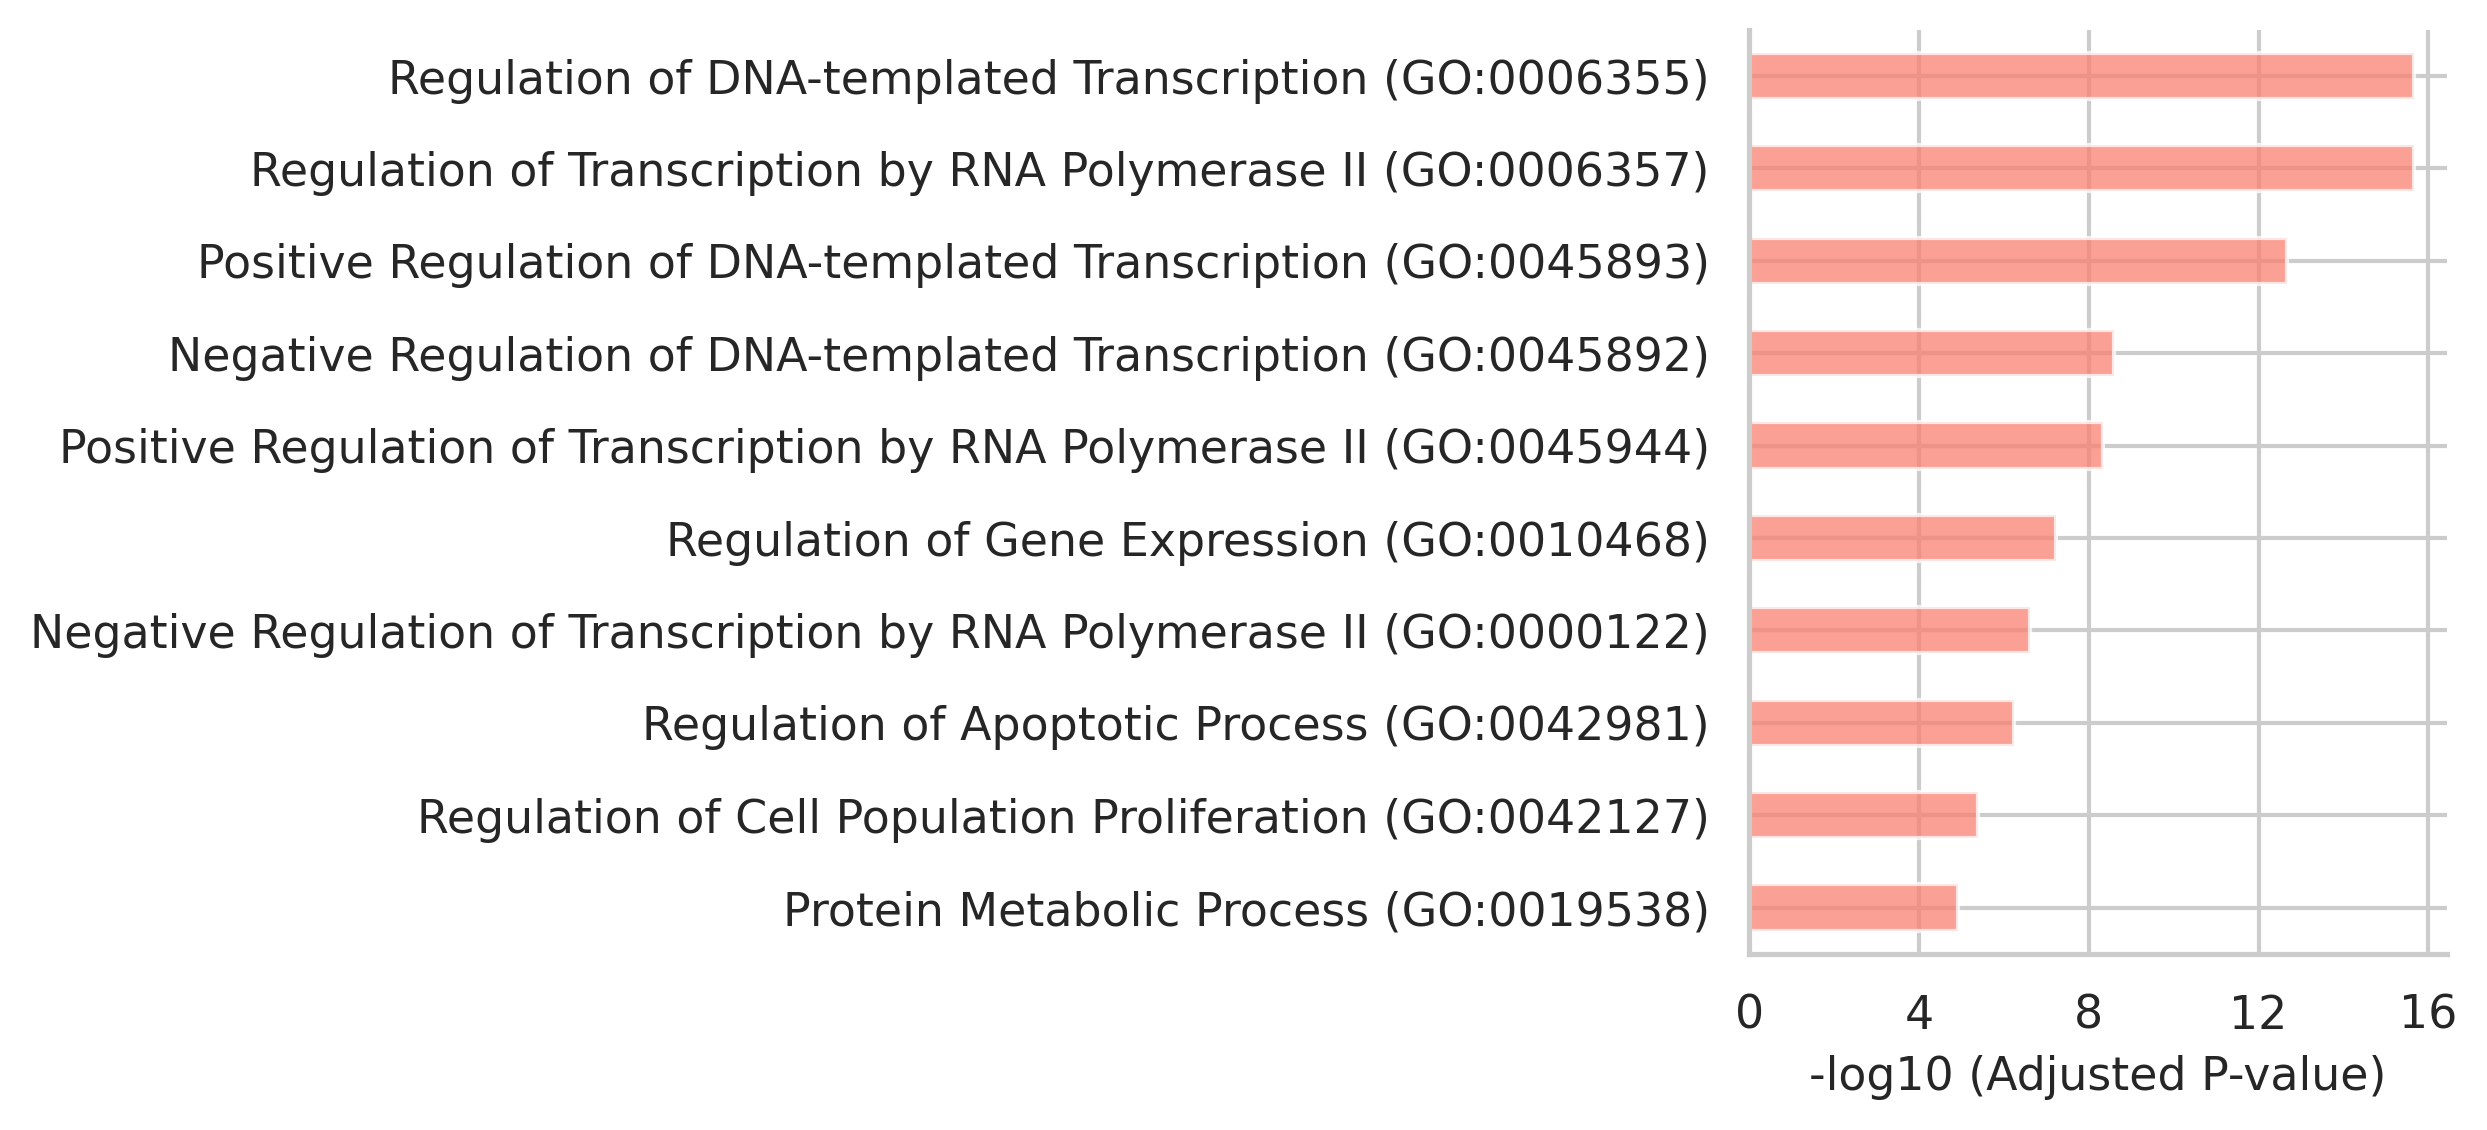

In [85]:
from gseapy import barplot
import seaborn as sb; sb.set(style="whitegrid")

ax = barplot(enr_res1.results,
              column="Adjusted P-value",
              size=5,
              top_term=10,
              figsize=(3, 4),
              color={'GO_Biological_Process_2025': 'salmon'}
             )

# Decrease font size
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)

# Remove bold from x-axis label
ax.set_xlabel("-log10 (Adjusted P-value)", fontsize=11, fontweight='normal')

# Save the figure as a PDF
fig = ax.get_figure()
fig.savefig('./enrichment_barplot.pdf', bbox_inches='tight', dpi=300)